## ANN / MLP 

Prototype 1
- The dataset is fashion MNIST (70k 28x28)
- Whole dataset won't be trained better to use a subset of 6k images
- Architecture
    - input layer - 784 nodes
    - 2 hidden layers 
        1- 128 neurons - ReLu
        2- 64 neurons - ReLu
    - output layer - softmax 

- Workflow
    - Dataloader objects for training and testing 
    - Training loop 
    - Eval code on testing data

Improvement 1 - Train the dataset on GPU 
pager memory to pin memory takes time better to directly go to pin memory

#### Problem
1) the model is overfitting 
 - solutions
    - add more data 
    - Reduce the complexity of NN architecture
    - Regularization - Loss + penalty (l1 or l2) *
    - Dropouts - some neurons are turned off during training randomly *
    - Data Augmentation - data is modified such that we get many variations of the same image (usually used in CNN architecture)
    - Batch Normalization - A bit of regularisation *
    - Early Stopping - we stop early as convgerges early

#### HOW - Improvement 2
1) Dropouts 
   - Applied to hidden layers
   - Applied after Relu activation
   - Randomly turns off p% neurons in hidden layers during each forward pass
   - This has regularization effect
   - During eval dropout is not used

2) Batch normalisation - every weight update is normalised
      - Applied to hidden layer but not output layer
      - Applied to linear layers before activation function
      - Includes Learnable Params
      - Improves training stability
      - regularization effect

3) Regularization
      -just add a penalty term Asum(wi^2)
      - we can do this by weight decay
      - Penalizes large weights
      - biases are not affected

Overfitting reduced - train - 94% and test - 88%


### Improvement 3

We dont know the best architecture for this hence we start experimentation for every possible parameter for the best value of params
-  use Basian Search by Optuna

#### plan of action
This would be the sequence 2 times 

    - Number of hidden layers
    - Neurons per layer
    - Number of epochs
    - Optimizer
    - Learning rate
    - Batch size 
    - Dropout rate
    - Weight decay

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch 
from torch.utils.data import DataLoader,Dataset
import torch.nn as nn 
import torch.optim as optim
import matplotlib.pyplot as plt
import optuna

In [27]:
torch.manual_seed(42)

In [28]:
df = pd.read_csv("fashion-mnist_train.csv")
df2 = pd.read_csv("fashion-mnist_test.csv")
df2.shape

(10000, 785)

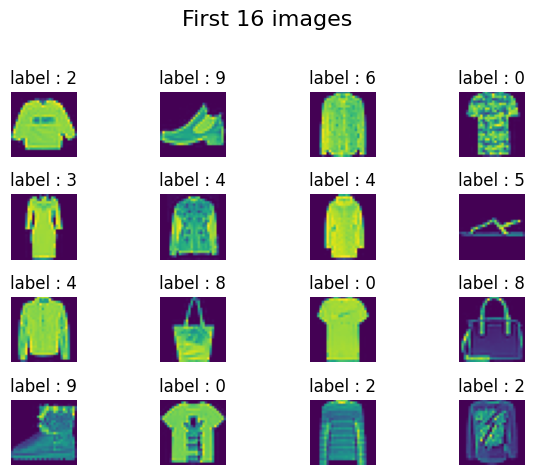

In [29]:
fig , axes = plt.subplots(4,4)
fig.suptitle("First 16 images" , fontsize = 16)

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28) # reshape to 28x28
    ax.imshow(img) #display in grayscale
    ax.axis('off')
    ax.set_title(f"label : {df.iloc[i,0]}")
plt.tight_layout(rect= [0,0,1,0.96])
plt.show()

In [30]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values
# test dataset
X_v = df2.iloc[:,1:].values
y_v = df2.iloc[:,0].values

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_valid , y_valid = X_v , y_v

In [32]:
# scaling the features (0-1)
# advisable to scale
X_train = X_train/255.0
X_test = X_test/255.0
X_valid = X_valid/255.0
y_valid = y_valid/255.0

In [33]:
class CustomDataSet(Dataset):
    def __init__(self,features,labels):
        self.features = torch.tensor(features,dtype = torch.float32)
        self.labels = torch.tensor(labels , dtype = torch.long)
    def __len__(self):
        return len(self.features)
    def __getitem__(self, index):
        return self.features[index] , self.labels[index]

In [34]:
train_dataset = CustomDataSet(X_train, y_train)
test_dataset = CustomDataSet(X_test,y_test)
validation_dataset = CustomDataSet(X_valid,y_valid)

In [35]:
train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle = True ,pin_memory = True)
test_loader = DataLoader(test_dataset , batch_size = 32 , shuffle=False)
valid_loader = DataLoader(validation_dataset , batch_size = 32 , shuffle = False)

In [36]:
class MyNN(nn.Module):
    def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer):
        super().__init__()
        layers = []
        for i in range(num_hidden_layers):
            layers.append(nn.Linear(input_dim,neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            input_dim = neurons_per_layer
        layers.append(nn.Linear(neurons_per_layer,output_dim))

        self.model = nn.Sequential(*layers)  # unpack the layer
    def forward(self , x):
        return self.model(x)

In [37]:
device = torch.device('cuda')

In [38]:
import optuna

In [45]:
def objective(trial):
    # next hyperparameter values
    num_hidden_layer = trial.suggest_int("num_hidden_layers",1,5)
    neurons_per_layer = trial.suggest_int("neurons_per_layer",8,128, step = 8)
    # model initialize
    input_dim = 784
    output_dim = 10
    model = MyNN(input_dim,output_dim,num_hidden_layer,neurons_per_layer)
    model.to(device)
    # params init
    epochs = 100 
    learning_rate = 0.1
    # optimiser select
    # instantiate model
    #loss fxn
    criterion = nn.CrossEntropyLoss()
    #optimizer
    optimiser = optim.SGD(model.parameters() , lr = learning_rate , weight_decay=1e-4)
    # training loop 
    for epoch in range(epochs):
        total_epoch_loss = 0
        for batch_features , batch_labels in train_loader:
            # move data to gpu 
            batch_features,batch_labels = batch_features.to(device) , batch_labels.to(device)
            # forward pass
            outputs = model(batch_features) 
            # calculate loss
            loss = criterion(outputs,batch_labels)
            # back pass 
            optimiser.zero_grad()
            loss.backward()
            # update grads
            optimiser.step()
            total_epoch_loss = total_epoch_loss + loss.item()
    # eval
    model.eval()
    total = 0 
    correct = 0

    with torch.no_grad():
        for batch_features,batch_labels in test_loader:
            batch_features,batch_labels = batch_features.to(device) , batch_labels.to(device)
            outputs = model(batch_features)
            _,predicted = torch.max(outputs,1)
            total = total + batch_labels.shape[0]
            correct = correct + (predicted == batch_labels).sum().item()
        accuracy = correct/total
    return accuracy

In [46]:
study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=10)

[I 2026-03-31 00:04:38,424] A new study created in memory with name: no-name-fef1f35b-b766-4fba-a53b-d4210dfb1794
[I 2026-03-31 00:09:07,427] Trial 0 finished with value: 0.8840833333333333 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 72}. Best is trial 0 with value: 0.8840833333333333.
[I 2026-03-31 00:16:41,709] Trial 1 finished with value: 0.8460833333333333 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 32}. Best is trial 0 with value: 0.8840833333333333.
[I 2026-03-31 00:24:22,008] Trial 2 finished with value: 0.875 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 56}. Best is trial 0 with value: 0.8840833333333333.
[I 2026-03-31 00:32:30,519] Trial 3 finished with value: 0.8805833333333334 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 56}. Best is trial 0 with value: 0.8840833333333333.
[I 2026-03-31 00:39:11,253] Trial 4 finished with value: 0.8768333333333334 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer

In [ ]:
class MyNN(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p = 0.3),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p = 0.3),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.model(x)

In [ ]:
# learning rate and epochs 
epochs = 100 
learning_rate = 0.1 
device = torch.device('cuda')

In [ ]:
# instantiate model
model = MyNN(X_train.shape[1])
model.to(device)
#loss fxn
criterion = nn.CrossEntropyLoss()
#optimizer
optimiser = optim.SGD(model.parameters() , lr = learning_rate , weight_decay=1e-4)

In [ ]:
# training loop
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features , batch_labels in train_loader:
        # move data to gpu 
        batch_features,batch_labels = batch_features.to(device) , batch_labels.to(device)
        # forward pass
        outputs = model(batch_features) 
        # calculate loss
        loss = criterion(outputs,batch_labels)
        # back pass 
        optimiser.zero_grad()
        loss.backward()
        # update grads
        optimiser.step()
        total_epoch_loss = total_epoch_loss + loss.item()
    avg_loss = total_epoch_loss/len(train_loader)
    print(f'Epoch: {epoch+1},Loss: {avg_loss}')


Epoch: 1,Loss: 0.6250404342214266
Epoch: 2,Loss: 0.49230208892623584
Epoch: 3,Loss: 0.45580852290491264
Epoch: 4,Loss: 0.4333279873728752
Epoch: 5,Loss: 0.41730037692189215
Epoch: 6,Loss: 0.40580502248803774
Epoch: 7,Loss: 0.3942960692842801
Epoch: 8,Loss: 0.38623938260475793
Epoch: 9,Loss: 0.3733836820522944
Epoch: 10,Loss: 0.3722042214125395
Epoch: 11,Loss: 0.36609405974547066
Epoch: 12,Loss: 0.35504184040427206
Epoch: 13,Loss: 0.34997388152281445
Epoch: 14,Loss: 0.34747496525446575
Epoch: 15,Loss: 0.3468074992050727
Epoch: 16,Loss: 0.3378263649294774
Epoch: 17,Loss: 0.33280676467716697
Epoch: 18,Loss: 0.33156502240896224
Epoch: 19,Loss: 0.3311940337345004
Epoch: 20,Loss: 0.3263203992048899
Epoch: 21,Loss: 0.321227067189912
Epoch: 22,Loss: 0.3197567942738533
Epoch: 23,Loss: 0.32282045533011355
Epoch: 24,Loss: 0.3155014213050405
Epoch: 25,Loss: 0.31408411511778833
Epoch: 26,Loss: 0.3167980548714598
Epoch: 27,Loss: 0.3104825288752715
Epoch: 28,Loss: 0.3071383638083935
Epoch: 29,Loss: 0

In [ ]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# model eval - some features are differnt in training and diff in test
# batch normalisation - we use trained stuff dont train it again 
total = 0 
correct = 0

with torch.no_grad():
    for batch_features,batch_labels in test_loader:
        batch_features,batch_labels = batch_features.to(device) , batch_labels.to(device)
        outputs = model(batch_features)
        _,predicted = torch.max(outputs,1)
        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()
    print(correct/total)

0.8894166666666666


In [ ]:
model.eval()
total = 0 
correct = 0
with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device) , batch_labels.to(device)
        outputs = model(batch_features)
        _,predicted = torch.max(outputs,1)
        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()
    print(correct/total)

0.9430208333333333


In [ ]:
import optuna